In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append("../Holistic-Explainer")
from test_dataset_BPR import get_eval_dataset_loader
from data_utils import *
from utils import seedSet,load_checkpoint,verify_model_weights

/home/sairamv/anaconda3/lib/python3.8/site-packages/setuptools/distutils_patch.py:25: UserWarning: Distutils was imported before Setuptools. This usage is discouraged and may exhibit undesirable behaviors or errors. Please use Setuptools' objects directly or at least import Setuptools first.
  warnings.warn(


In [2]:
def standardize(x,epsilon=1e-6):
    x_std = (x - x.mean()) / (x.std() + epsilon)
    return x_std


def utility_relevance_loss(labels, scores):
    relevance_loss = F.binary_cross_entropy_with_logits(scores, labels)
    return relevance_loss

# Stage 1: BPR Explanation Pairwise Loss
def bpr_loss(pos_score, neg_score):
    diff = pos_score - neg_score
    diff = diff.clamp(min=-10, max=10)
    return -torch.mean(F.logsigmoid(diff))

# Zero explanation embedding for neutral scoring
def build_zero_expl(model, tokenizer, device, batch_size, max_length=512):
    input_ids = torch.full((batch_size, max_length), tokenizer.pad_token_id, dtype=torch.long).to(device)
    attention_mask = torch.ones((batch_size, max_length), dtype=torch.long).to(device)  # force decoder to ignore all tokens

    with torch.no_grad():
        output = model(input_ids=input_ids, attention_mask=attention_mask)

    # Safe zero vector if required
    zero_embed = output.hidden_states[-1].mean(dim=1)
    
    return zero_embed  # (1, D)

# Helper to get explanation embeddings from frozen LLaMA model
def get_explanation_embedding(encoder, tokenizer, text, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True,max_length=512).to(device)
    with torch.no_grad():
        output = encoder(**inputs)
    
    return output.hidden_states[-1].mean(dim=1)  # Mean pooling


In [3]:
class DeepFM(nn.Module):
    def __init__(self, user_num, item_num, id_embed_dim, expl_embed_dim, hidden_dims, dropout_rate = 0.2):
        super().__init__()
        self.user_embed = nn.Embedding(user_num, id_embed_dim)
        self.item_embed = nn.Embedding(item_num, id_embed_dim)
        
        expl_dim = id_embed_dim

        # Linear (first-order term)
        self.linear = nn.Linear(id_embed_dim * 2 + expl_embed_dim, 1)
        
        
        self.input_norm = nn.LayerNorm(id_embed_dim * 2 + expl_embed_dim)

        self.expl_proj = nn.Linear(expl_embed_dim, expl_dim)

        # Deep component
        deep_input_dim = id_embed_dim * 2 + expl_embed_dim
        layers = []
        for h in hidden_dims:
            layers.append(nn.Linear(deep_input_dim, h))
            layers.append(nn.LayerNorm(h)) # ADDED JUNE 18
            layers.append(nn.ReLU())
            deep_input_dim = h
        self.deep = nn.Sequential(*layers)
        self.deep_out = nn.Linear(hidden_dims[-1], 1)
        
        nn.init.xavier_uniform_(self.linear.weight, gain=0.1)
        nn.init.xavier_uniform_(self.deep_out.weight, gain=0.1)
        nn.init.xavier_uniform_(self.expl_proj.weight, gain=0.1)

        # FM second-order interaction
        self.dropout = nn.Dropout(dropout_rate)
    
    def fm_interaction(self, x):
        sum_square = torch.sum(x, dim=1) ** 2
        square_sum = torch.sum(x ** 2, dim=1)
        interaction = 0.5 * (sum_square - square_sum)
        return torch.sum(interaction, dim=1, keepdim=True)
    
    def forward_hidden(self, user_ids, item_ids, expl_embeds):
        """
        Returns the hidden representation produced by the deep network
        BEFORE the final linear layer (deep_out).
        """

        # (Same preprocessing as forward)
        u = self.user_embed(user_ids)
        i = self.item_embed(item_ids)

        expl_embeds = F.normalize(expl_embeds, p=2, dim=-1)
        e = self.expl_proj(expl_embeds)

        concat_feats = torch.cat([u, i, expl_embeds], dim=-1)
        # concat_feats = self.input_norm(concat_feats)

        # Deep hidden representation
        hidden = self.deep(concat_feats)   # shape (B, H)

        return hidden

    def forward(self, user_ids, item_ids, expl_embeds,mild_factor_scale=0.4):
        u = self.user_embed(user_ids)
        i = self.item_embed(item_ids)
        
        expl_embeds = F.normalize(expl_embeds, p=2, dim=-1)
        e = self.expl_proj(expl_embeds)

        feats = torch.stack([u, i, e], dim=1)  # shape (B, 3, D)
        concat_feats = torch.cat([u, i, expl_embeds], dim=-1)  # shape (B, 2*ID_dim + expl_dim)
        
        linear_out = self.linear(concat_feats) # self.linear_norm(self.linear(concat_feats))
        fm_out = self.fm_interaction(feats) # self.fm_norm(self.fm_interaction(feats))
        
        deep_out = self.deep(concat_feats)
        deep_out = self.deep_out(self.dropout(deep_out))
        
        score = linear_out + fm_out + deep_out

        score *= mild_factor_scale
        return score

    def freeze_component(self, component_names):
        for name in component_names:
            module = getattr(self, name, None)
            if module is not None:
                for param in module.parameters():
                    param.requires_grad = False
                print(f"param: {name} is frozen")
    

In [4]:
DATASET = "beauty"
EXPL_PATH = '../Holistic-Explainer/generated-expls/'
DATA_PATH = "../data"
ID_EMBED_DIM = 64
HIDDEN_DIM = [256,128,64]
STAGE1_CKPT = f'../Holistic-Explainer/snap/{DATASET}/stage-0/checkpoint_epoch_BEST.pt'
STAGE2_CKPT = f'../Holistic-Explainer/snap/{DATASET}/stage-1/checkpoint_epoch_BEST.pt'
dropout = 0.0
local_rank = 0
seed=999

In [5]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append("../Holistic-Explainer")
from test_dataset_BPR import get_eval_dataset_loader
from data_utils import *
from utils import seedSet,load_checkpoint

In [6]:
datamaps = load_json(f"{DATA_PATH}/{DATASET}/datamaps.json")
USER_NUM = len(datamaps['user2id'])
ITEM_NUM = len(datamaps['item2id'])

In [7]:
expls = load_pickle(os.path.join(EXPL_PATH, DATASET, "train.pkl"))
targetItems = readTargetItem(os.path.join(DATA_PATH, DATASET, "targetItems.txt"))
_, eval_dataset = get_eval_dataset_loader(datamaps = datamaps, 
                                          targetItems = targetItems, 
                                          user_num = USER_NUM, 
                                          item_num = ITEM_NUM, 
                                          mode='test',
                                          batch_size=100, 
                                          dataset = DATASET, 
                                          data_path = DATA_PATH, 
                                          expls = expls, 
                                          workers=0, 
                                          shuffle=False)

USER_NUM=eval_dataset.user_num
ITEM_NUM=eval_dataset.item_num
val_data = eval_dataset.get_val_items()

[INFO] Mode: test, Dataset Size: 2236300, DataLoader Size: 22363


In [8]:
list(val_data.items())[0]

(0, 4)

In [9]:
device = torch.device(f"cuda:{local_rank}")
device_map={"": local_rank}
torch.cuda.set_device(device)  # Assign unique GPU to each rank
seedSet(seed)

In [10]:
def get_model(USER_NUM,
              ITEM_NUM,
              ID_EMBED_DIM,
              HIDDEN_DIM,
              dropout=0,
              local_rank=0,
              device=None
             ):
    
    model_name = "meta-llama/Llama-2-7b-hf"
    tokenizer = AutoTokenizer.from_pretrained(model_name,use_auth_token="YOUR_HF_TOKEN")
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side='left' # ADDED BY ME to avoid error for decoder-only model

    encoder = AutoModelForCausalLM.from_pretrained(model_name,torch_dtype=torch.float16,token="YOUR_HF_TOKEN",device_map=device_map,output_hidden_states=True).eval()

    model = DeepFM(user_num = USER_NUM, item_num = ITEM_NUM, id_embed_dim = ID_EMBED_DIM, expl_embed_dim = encoder.config.hidden_size, hidden_dims=HIDDEN_DIM, dropout_rate = dropout).to(device)

    model = model.to(f"cuda:{local_rank}")
    model.eval()
    return model,tokenizer,encoder

In [11]:
model,tokenizer,encoder = get_model(USER_NUM,
              ITEM_NUM,
              ID_EMBED_DIM,
              HIDDEN_DIM,
              dropout=dropout,
              local_rank=local_rank,
              device=device
             )
stage1_model = load_checkpoint(model, STAGE1_CKPT)
verify_model_weights(stage1_model)

/home/sairamv/anaconda3/lib/python3.8/site-packages/transformers/models/auto/tokenization_auto.py:809: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/sairamv/anaconda3/lib/python3.8/site-packages/transformers/generation/configuration_utils.py:774: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Resume checkpoint from ../Holistic-Explainer/snap/beauty/stage-0/checkpoint_epoch_BEST.pt
user_embed.weight → torch.Size([22364, 64]) -> 0.9753845930099487
item_embed.weight → torch.Size([12102, 64]) -> 1.1312373876571655
linear.weight → torch.Size([1, 4224]) -> 0.012770747765898705
linear.bias → torch.Size([1]) -> 0.004683322738856077
input_norm.weight → torch.Size([4224]) -> 0.012380178086459637
input_norm.bias → torch.Size([4224]) -> 0.0645497515797615
expl_proj.weight → torch.Size([64, 4096]) -> 0.0019015182042494416
expl_proj.bias → torch.Size([64]) -> 0.29030412435531616
deep.0.weight → torch.Size([256, 4224]) -> 0.022044526413083076
deep.0.bias → torch.Size([256]) -> 0.03403603285551071
deep.1.weight → torch.Size([256]) -> 0.9930632710456848
deep.1.bias → torch.Size([256]) -> 0.09059630334377289
deep.3.weight → torch.Size([128, 256]) -> 0.04025724530220032
deep.3.bias → torch.Size([128]) -> 0.04205343872308731
deep.4.weight → torch.Size([128]) -> 0.9656140208244324
deep.4.bias →

../Holistic-Explainer/utils.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(url_or_filename)


In [12]:
model,tokenizer,encoder = get_model(USER_NUM,
              ITEM_NUM,
              ID_EMBED_DIM,
              HIDDEN_DIM,
              dropout=dropout,
              local_rank=local_rank,
              device=device
             )
stage2_model = load_checkpoint(model, STAGE2_CKPT)
verify_model_weights(stage2_model)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Resume checkpoint from ../Holistic-Explainer/snap/beauty/stage-1/checkpoint_epoch_BEST.pt
user_embed.weight → torch.Size([22364, 64]) -> 0.9753845930099487
item_embed.weight → torch.Size([12102, 64]) -> 1.1312373876571655
linear.weight → torch.Size([1, 4224]) -> 0.3904809057712555
linear.bias → torch.Size([1]) -> 0.004683322738856077
input_norm.weight → torch.Size([4224]) -> 0.012380178086459637
input_norm.bias → torch.Size([4224]) -> 0.0645497515797615
expl_proj.weight → torch.Size([64, 4096]) -> 0.06458693742752075
expl_proj.bias → torch.Size([64]) -> 0.29018324613571167
deep.0.weight → torch.Size([256, 4224]) -> 0.08459223061800003
deep.0.bias → torch.Size([256]) -> 0.08193008601665497
deep.1.weight → torch.Size([256]) -> 0.8081298470497131
deep.1.bias → torch.Size([256]) -> 0.15530619025230408
deep.3.weight → torch.Size([128, 256]) -> 0.0859391987323761
deep.3.bias → torch.Size([128]) -> 0.09872373938560486
deep.4.weight → torch.Size([128]) -> 1.1016879081726074
deep.4.bias → torch

In [13]:
TSNE_SAMPLES = len(val_data)

In [14]:
# ------------------------------------------------------------
# Compute h1 (Stage 1) and h2 (Stage 2)
# ------------------------------------------------------------

h1_list = []
h2_list = []


print("Extracting contextual representations...")
for k in tqdm(list(val_data.items())[:TSNE_SAMPLES]):
    with autocast(dtype=torch.float16):

        sample = expls[k]
        sample['user_id'] = k[0]
        sample['item_id'] = k[1]
        user_id = torch.tensor([sample["user_id"]], dtype=torch.long).to(device)
        item_id = torch.tensor([sample["item_id"]], dtype=torch.long).to(device)

        # Stage 1: ZERO explanation
        zero_expl = torch.zeros((len(user_id), encoder.config.hidden_size), dtype=torch.float16).to(device) 
        with torch.no_grad():
            h1 = stage1_model.forward_hidden(user_id, item_id, zero_expl)
        h1_list.append(h1.cpu().numpy())

        # Stage 2: POS explanation
        pos_emb = get_explanation_embedding(encoder, tokenizer, sample['pos-expl'], device)  # implement your encoder
        with torch.no_grad():
            h2 = stage2_model.forward_hidden(user_id, item_id, pos_emb)
        h2_list.append(h2.cpu().numpy())



h1_arr = np.vstack(h1_list)
h2_arr = np.vstack(h2_list)


# ------------------------------------------------------------
# Compute Δ representation shift
# ------------------------------------------------------------
delta = np.linalg.norm(h2_arr - h1_arr, axis=1)

print("\n=== Representation Shift Statistics ===")
print("Count:", len(delta))
print("Mean Δ:", delta.mean())
print("Median Δ:", np.median(delta))
print("Std Δ:", delta.std())
print("25%:", np.percentile(delta, 25))
print("75%:", np.percentile(delta, 75))

Extracting contextual representations...


  0%|          | 0/22363 [00:00<?, ?it/s]<ipython-input-14-46a77c501e6f>:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):
100%|██████████| 22363/22363 [09:50<00:00, 37.87it/s]


=== Representation Shift Statistics ===
Count: 22363
Mean Δ: 9.82991
Median Δ: 11.224477
Std Δ: 2.9290624
25%: 8.367272853851318
75%: 12.072359561920166


In [15]:
with open("beauty-repr.pkl",'wb') as h:
    pickle.dump({'s1':h1_arr,'s2':h2_arr},h)

In [16]:

# ------------------------------------------------------------
# t-SNE Visualization (Stage 1 vs Stage 2)
# ------------------------------------------------------------
idx = np.random.choice(len(delta), TSNE_SAMPLES, replace=False)

tsne_input = np.vstack([h1_arr[idx], h2_arr[idx]])

tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=seed)
tsne_out = tsne.fit_transform(tsne_input)

mean_shift = delta.mean()


AttributeError: 'NoneType' object has no attribute 'split'

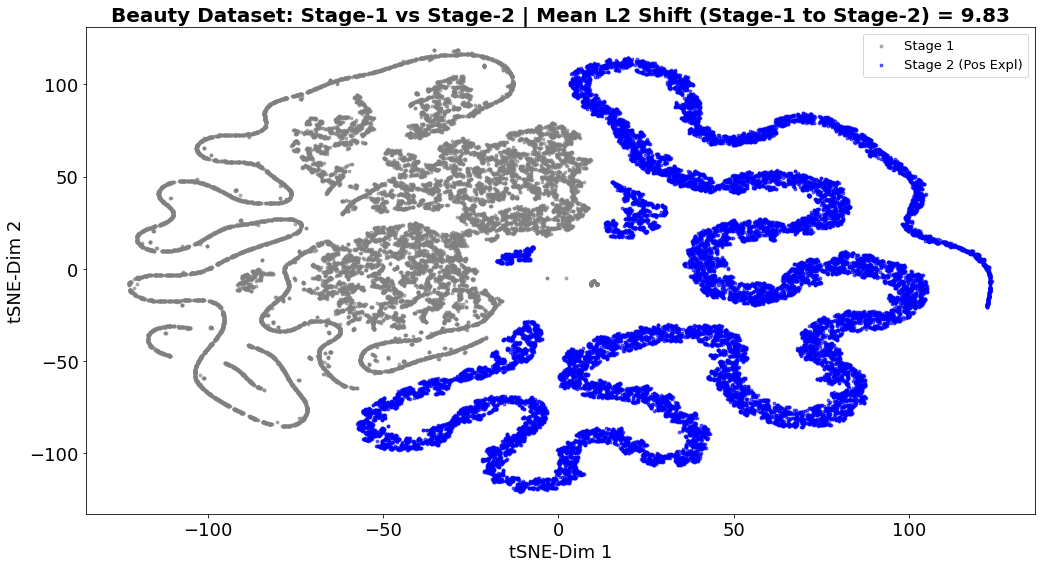

In [19]:

plt.figure(figsize=(15,8))
plt.scatter(tsne_out[:TSNE_SAMPLES,0], tsne_out[:TSNE_SAMPLES,1],
            s=8, alpha=0.6, label="Stage 1", color="gray")
plt.scatter(tsne_out[TSNE_SAMPLES:,0], tsne_out[TSNE_SAMPLES:,1],
            s=8, alpha=0.6, label="Stage 2 (Pos Expl)", color="blue")

plt.legend(fontsize=13)
plt.tick_params(axis='both', labelsize=18)
plt.title(f"{DATASET.capitalize()} Dataset: Stage-1 vs Stage-2 | Mean L2 Shift (Stage-1 to Stage-2) = {mean_shift:.2f}",
          fontsize=20,fontweight='bold')
plt.xlabel("tSNE-Dim 1",fontsize=18)
plt.ylabel("tSNE-Dim 2",fontsize=18)
plt.tight_layout()
# plt.savefig("tsne_stage1_stage2.png", dpi=300)
plt.show()